In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from functions import *
import warnings

In [12]:

def spherical_to_cartesian(azimuth_deg, elevation_deg):
    """Конвертируем углы в направляющий вектор"""
    azimuth = np.radians(azimuth_deg)
    elevation = np.radians(elevation_deg)
    x = np.cos(elevation) * np.cos(azimuth)
    y = np.cos(elevation) * np.sin(azimuth)
    z = np.sin(elevation)
    return np.array([x, y, z])

def line_parametric(t, origin, direction):
    """Параметрическое уравнение прямой"""
    return origin + direction * t

def find_intersection(matrix_shape, origin, direction):
    """Находим точки пересечения прямой с границами матрицы"""
    def get_t(axis, boundary):
        return (boundary - origin[axis]) / direction[axis] if direction[axis] != 0 else np.nan
    
    min_bounds = np.array([0, 0, 0])
    max_bounds = np.array(matrix_shape) - 1e-6  #  краевые эффекты
    
    t_enter = []
    t_exit = []
    
    for i in range(3):
        t1 = get_t(i, min_bounds[i])
        t2 = get_t(i, max_bounds[i])
        t_enter.append(min(t1, t2))
        t_exit.append(max(t1, t2))
    
    # Исправленный блок 
    valid_t_enter = [t for t in t_enter if not np.isnan(t)]
    valid_t_exit = [t for t in t_exit if not np.isnan(t)]
    
    t_start = max([0] + valid_t_enter) if valid_t_enter else np.nan 
    t_end = min(valid_t_exit) if valid_t_exit else np.nan    
    
    if np.isnan(t_start) or np.isnan(t_end) or t_start > t_end:
        return np.nan, np.nan
    
    
    # t_start = max(0, *[t for t in t_enter if not np.isnan(t)])
    # t_end = min(*[t for t in t_exit if not np.isnan(t)])
    
    return t_start, t_end

def trilinear_interpolation(matrix, x, y, z):
    """Трилинейная интерполяция"""
    x0, y0, z0 = np.floor([x, y, z]).astype(int)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    
    # обработка выхода за границы
    x0, x1 = np.clip([x0, x1], 0, matrix.shape[0]-1)
    y0, y1 = np.clip([y0, y1], 0, matrix.shape[1]-1)
    z0, z1 = np.clip([z0, z1], 0, matrix.shape[2]-1)
    
    xd = (x - x0) / (x1 - x0) if (x1 - x0) != 0 else 0
    yd = (y - y0) / (y1 - y0) if (y1 - y0) != 0 else 0
    zd = (z - z0) / (z1 - z0) if (z1 - z0) != 0 else 0

    c00 = matrix[x0, y0, z0] * (1 - xd) + matrix[x1, y0, z0] * xd
    c01 = matrix[x0, y0, z1] * (1 - xd) + matrix[x1, y0, z1] * xd
    c10 = matrix[x0, y1, z0] * (1 - xd) + matrix[x1, y1, z0] * xd
    c11 = matrix[x0, y1, z1] * (1 - xd) + matrix[x1, y1, z1] * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd

def calculate_F_factor(values, distance):
    dv_ds = np.gradient(values, distance)
    # print("dv_ds:\n", dv_ds)
    #  ускорение (a = v * dv/ds)
    dt = np.gradient(distance) / np.gradient(distance).mean()  # Приближенное dt
    acceleration = dv_ds / dt
    # print("acceleration:\n",acceleration)
    # Расчет F-фактора для каждой точки с окном 1 км
    g = 9.81  # Ускорение свободного падения
    f_factors = []

    for i in range(len(distance)):
        current_dist = distance[i]
        start_dist = current_dist - 500  # 500 метров назад
        end_dist = current_dist + 500    # 500 метров вперед
        
        # Находим индексы границ окна
        left_idx = np.searchsorted(distance, start_dist, side='left')
        right_idx = np.searchsorted(distance, end_dist, side='right')
        
        # Ограничиваем индексы границами массива
        left_idx = max(0, left_idx)
        right_idx = min(len(distance), right_idx)
        
        # Усредняем ускорения в окне
        window_accel = acceleration[left_idx:right_idx]
        if len(window_accel) == 0:
            f_factor = np.nan
        else:
            mean_accel = np.mean(window_accel)
            f_factor = mean_accel  #/g # F-фактор
        # print(f"distance: {current_dist}; f-factor {f_factor}; left ")
        
        f_factors.append(f_factor)
    # print("f_factors:\n", f_factors)
    return f_factors

In [13]:
def plot_line_results(V_radial, z0, x, y, z, points, values, 
                     values_rrf, f_factors, distance, observer_position):
    """
    Визуализация результатов: радиальная скорость и объединенные профили.
    
    Args:
        V_radial (np.ndarray): 3D массив радиальных скоростей.
        z0 (int): Величина в метрах среза Z.
        x (np.ndarray): Координаты по оси X.
        y (np.ndarray): Координаты по оси Y.
        z (np.ndarray): Координаты по оси Z.
        points (np.ndarray): Точки на линии (X, Y, Z).
        values (list): Значения радиальной скорости.
        values_rrf (list): Значения RRF.
        f_factors (list): Значения F-factor.
        distance (np.ndarray): Расстояния вдоль линии.
        observer_position (tuple): Позиция наблюдателя (x0, y0).
    """

    z_slice = np.argmin(np.abs(z - z0))  # Индекс слоя z

    # Срез радиальной скорости
    radial_slice = V_radial[:, :, z_slice]

    plt.figure(figsize=(14, 12))  # Увеличение высоты для двух графиков

    # Подграфик 1: Вид сверху
    plt.subplot(2, 1, 1)
    plt.imshow(
        radial_slice.T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Радиальная скорость (м/с)')

    # Точки линии
    plt.scatter(
        points[:, 0], points[:, 1],
        c=values, cmap='coolwarm', s=50, edgecolor='w',
        label='Точки линии'
    )
    plt.plot(points[:, 0], points[:, 1], 
             color='blue', linestyle='-', linewidth=2, label='Линия')
    
    # Наблюдатель
    plt.scatter(
        observer_position[0], observer_position[1],
        color='red', marker='X', s=100, label='Наблюдатель'
    )

    # Подписи значений у точек
    for i in range(len(points)):
        plt.text(
            points[i, 0], points[i, 1],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.title(f'Вид сверху (z={z0} м)')
    plt.legend()
    plt.grid(True)

    # Подграфик 2: Объединенные профили
    fig, ax1 = plt.subplots(figsize=(14,8))     
    ax1 = plt.gca()
    
    # Нормализация Z-значений
    z_values = points[:, 2]
    z_min, z_max = z_values.min(), z_values.max()
    v_min, v_max = min(values), max(values)
    # Проверка на случай константного Z
    if z_max != z_min:
        scaled_z = (z_values - z_min) / (z_max - z_min) * (v_max - v_min) + v_min
        scaled_z += (v_max - v_min) * 0.2  # Смещение на 20%
    else:
        # Если Z не меняется, используем среднее значение диапазона скоростей
        scaled_z = np.full_like(z_values, (v_max + v_min)/2) 

    # Линии
    ax1.plot(distance, values, 
             label='Радиальная скорость', marker='o', color='r')
    ax1.plot(distance, values_rrf, 
             label='RRF', linestyle='--', color='b')
    ax1.plot(distance, scaled_z, 
             label='Изменения по Z', color='g')

    # Оформление осей
    ax1.set_xlabel('Расстояние, м')
    ax1.set_ylabel('Скорость, м/с')
    ax1.set_title('Объединенные данные')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    # Вторая ось для F-factor
    ax2 = ax1.twinx()
    ax2.plot(distance, f_factors, 
             label='F Factor', linestyle='-.', color='k')
    ax2.set_ylabel('F Factor')
    ax2.legend(loc='upper right')

    # Подписи значений
    for i in range(len(distance)):
        ax1.text(
            distance[i], values[i],
            f'{values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    # Настройка пределов
    # print(values, "\n\n", values_rrf, "\n\n", scaled_z)
    all_values = np.concatenate([values, values_rrf, scaled_z])
    # print("\n\n", all_values)
    ax1.set_ylim(all_values.min()-10, all_values.max()+10)

    plt.tight_layout()
    plt.show()

In [14]:
u_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-u-48min.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-v-48min.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-w-48min.faa")
rrf_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-rrf-48min.faa") #Реальные координаты максимального элемента: [np.float64(-3906.0), np.float64(33836.0), np.float64(5100.0)]

In [15]:
print_pws_files_data(["../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-rrf-48min.faa"])

Processing file: ../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-rrf-48min.faa
Metadata:
  Title: TASS
  Variable: RRF
  Dimensions (x, y, z): (253, 254, 61)
  Simulation Time (seconds): 2880.4
  Origin (x, y, z) in meters: (-15906.0, 21936.0, 5000.0)
  Resolution (dx, dy, dz) in meters: (100.0, 100.0, 100.0)

Sample Data:
[[[-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  ...
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]]

 [[-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  ...
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]
  [-15.01 -15.01 -15.01 ... -15.01 -15.01 -15.01]]

 [[-15.01 -1

In [16]:

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки
print(dx, dy, dz)

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# print(x, y, z)
print("x valid:", np.all(np.isfinite(x)))
print("y valid:", np.all(np.isfinite(y)))
print("z valid:", np.all(np.isfinite(z)))

# Расчет радиальной скорости
# x0, y0, z0 =  -900, 0, 63 # Точка наблюдателя
x0, y0, z0 =  -15000, 33836, 5100 # Точка наблюдателя 
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = 0  # Вертикальный угол
num_points = 30    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])zz
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  


warnings.filterwarnings('error')

radial_velocity_values = []
for point in points:
    try:
        x_idx = (point[0] - origin[0]) / dx
        y_idx = (point[1] - origin[1]) / dy
        z_idx = (point[2] - origin[2]) / dz
        if np.any(np.isnan([x_idx, y_idx, z_idx])):
            raise ValueError("Invalid interpolation indices (NaN encountered)")
        radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
    except RuntimeWarning as e:
        print(f"Произошла ошибка: {e}")
        print(f"\n{point[0]} - {origin[0]} / {dx}")
        print(f"\n{point[1]} - {origin[1]} / {dy}")
        print(f"\n{point[2]} - {origin[2]} / {dz}")
        raise ValueError(e) from e
        

# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

# # Шаги изменения
# dx = -85.86511509
# dy = 4.5

# first_x = points[0, 0]
# first_y = points[0, 1]
# first_z = points[0, 2]

# new_data = []
# for i in range(1, 100):
#     new_x = first_x + i * dx
#     new_y = first_y 
#     new_z = first_z + i * dy
#     new_data.append([new_x, new_y, new_z])

# new_data = np.array(new_data)

origin = np.array(rrf_data['origin_m'])  
dx, dy, dz = rrf_data['resolution_m']    
values_rrf = []
for point in points:
    try:
        x_idx = (point[0] - origin[0]) / dx
        y_idx = (point[1] - origin[1]) / dy
        z_idx = (point[2] - origin[2]) / dz
        values_rrf.append(trilinear_interpolation(rrf_data['data'], x_idx, y_idx, z_idx))
    except RuntimeWarning as e:
        print(f"Произошла ошибка: {e}")
        print(f"\n{point[0]} - {origin[0]} / {dx}")
        print(f"\n{point[1]} - {origin[1]} / {dy}")
        print(f"\n{point[2]} - {origin[2]} / {dz}")
        raise ValueError(e) from e
    
f_factors = calculate_F_factor(np.array(radial_velocity_values), distance)

100.0 100.0 100.0
x valid: True
y valid: True
z valid: True


In [17]:
len(values_rrf),len(radial_velocity_values),len(points),np.any(np.isnan(values_rrf)),np.any(np.isnan(radial_velocity_values)),np.any(np.isnan(points))  

(30, 30, 30, np.False_, np.False_, np.False_)

In [18]:
import numpy as np

origin = np.array(rrf_data['origin_m'])  
dx, dy, dz = rrf_data['resolution_m']    
print(origin)
flat_index = np.argmax(rrf_data['data'])
max_index = np.unravel_index(flat_index, rrf_data['data'].shape)

print("Максимальное значение: ", np.max(rrf_data['data']))
print("Индекс максимального элемента:", max_index)

real_coordinates = [
    origin[0] + max_index[0] * dx,
    origin[1] + max_index[1] * dy,
    origin[2] + max_index[2] * dz
]

print("Реальные координаты максимального элемента (в метрах):", real_coordinates)


[-15906.  21936.   5000.]
Максимальное значение:  58.2395
Индекс максимального элемента: (np.int64(120), np.int64(119), np.int64(1))
Реальные координаты максимального элемента (в метрах): [np.float64(-3906.0), np.float64(33836.0), np.float64(5100.0)]


In [19]:
points, values_rrf

(array([[-15000.        ,  33836.        ,   5100.        ],
        [-14162.27586552,  33836.        ,   5100.        ],
        [-13324.55173103,  33836.        ,   5100.        ],
        [-12486.82759655,  33836.        ,   5100.        ],
        [-11649.10346207,  33836.        ,   5100.        ],
        [-10811.37932759,  33836.        ,   5100.        ],
        [ -9973.6551931 ,  33836.        ,   5100.        ],
        [ -9135.93105862,  33836.        ,   5100.        ],
        [ -8298.20692414,  33836.        ,   5100.        ],
        [ -7460.48278966,  33836.        ,   5100.        ],
        [ -6622.75865517,  33836.        ,   5100.        ],
        [ -5785.03452069,  33836.        ,   5100.        ],
        [ -4947.31038621,  33836.        ,   5100.        ],
        [ -4109.58625172,  33836.        ,   5100.        ],
        [ -3271.86211724,  33836.        ,   5100.        ],
        [ -2434.13798276,  33836.        ,   5100.        ],
        [ -1596.41384828

In [20]:
# fig = go.Figure()

# fig.add_trace(go.Volume(
#     x=X.flatten(),
#     y=Y.flatten(),
#     z=Z.flatten(),
#     value=rrf_data['data'].flatten(),
#     opacity=0.1,
#     colorscale='Viridis',
#     # hoverinfo='skip',
#     showscale=True
# ))

# fig.add_trace(go.Scatter3d(
#     x=points[:, 0],
#     y=points[:, 1],
#     z=points[:, 2],
#     mode='lines+markers+text', 
#     line=dict(
#         color=values_rrf,
#         colorscale='Jet',
#         width=3
#     ),
#     marker=dict(
#         size=5,
#         color=values_rrf,
#         colorscale='Jet'
#     ),
#     text=[f'{v:.2f}' for v in values_rrf],  
#     name='Линия наблюдения'
# ))

# fig.update_layout(
#     scene=dict(
#         xaxis_title='X (м)',
#         yaxis_title='Y (м)',
#         zaxis_title='Z (м)',
#         aspectmode='data',
#     ),
#     width=1200,
#     height=800,
#     title='Линия наблюдения в поле радиальной скорости'
# )

# # fig.show()

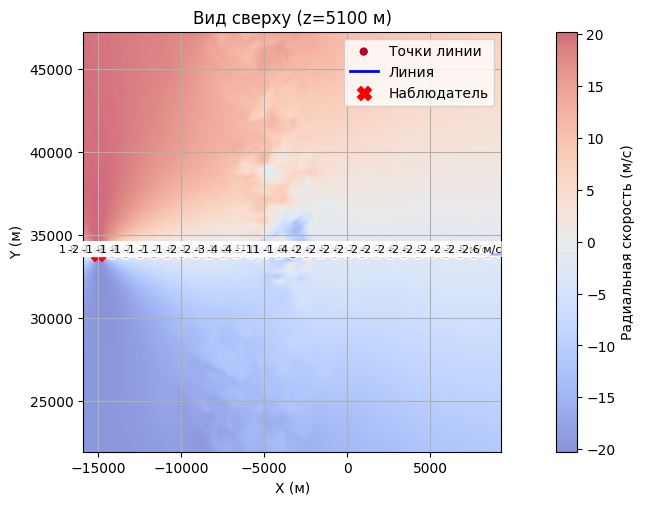

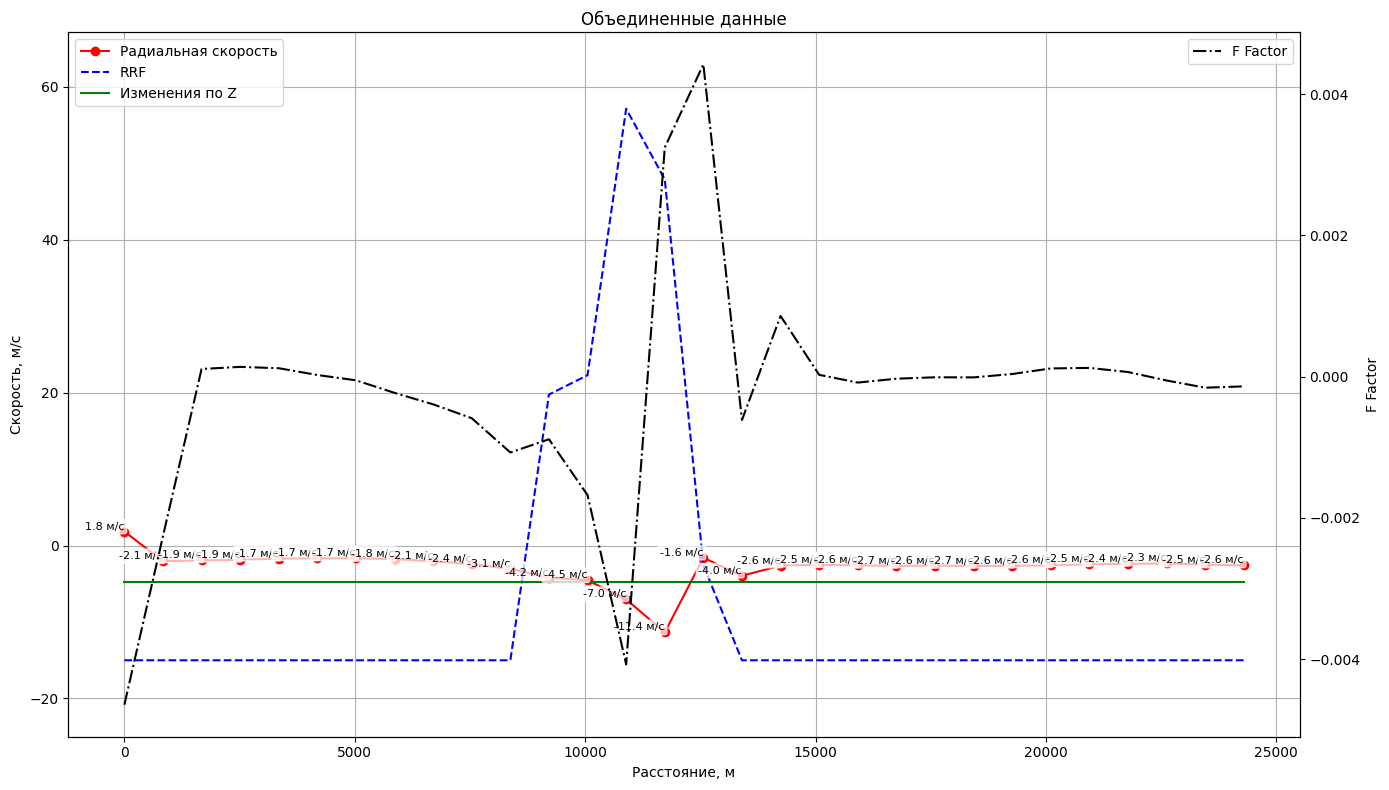

In [21]:
plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, values_rrf, f_factors, distance, observer_position=(x0, y0))

In [22]:
rrf_data['data'][120,119,1]

np.float64(58.2395)